# DDSP Model Evaluation

This notebook loads a trained DDSP model from a training directory,
takes random chunks from a dataset, runs a forward pass, and evaluates
reconstruction quality via:

- **MSE** (mean squared error)
- **Multi-resolution spectral loss** (MRSTFT via `auraloss`)
- **Overlaid magnitude spectra** (original vs. synthesised)
- **Waveform comparison** plots
- **Playback** of original and synthesised audio (IPython widgets)

In [1]:
# Configuration - edit these paths

MODEL_TRAINING_DIR = "../training/synth/ddsp_complex_sine"
DATASET_PATH       = "/mnt/mariadata/datasets/surrogate/single_sound/processed"
# MODEL_TRAINING_DIR = "../training/synth/violin_features"
# DATASET_PATH       = "/mnt/mariadata/datasets/surrogate/single_sound/processed"

# Audio parameters (must match the config used for training)
SAMPLE_RATE        = 44100
CHUNK_DURATION_S   = 2.0
RESAMPLING_FACTOR  = 32

# How many random chunks to evaluate
NUM_SAMPLES        = 3

DEVICE = "cuda"  # "cuda" or "cpu"

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import auraloss.freq
from IPython.display import Audio, display

from ddsp import DDSP, AudioFeatureDataset
from ddsp.utils import find_checkpoint
from ddsp.interfaces import ControlField, ControlSpace, build_control_space

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
torch.set_grad_enabled(False)

print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")

PyTorch 2.1.2+cu121  |  CUDA available: True


## 1 - Load the trained model

In [3]:
checkpoint_path = find_checkpoint(MODEL_TRAINING_DIR, typ="best")
print(f"Loading checkpoint: {checkpoint_path}")

# Reconstruct minimal ControlSpace from checkpoint hyperparameters
ckpt = torch.load(checkpoint_path, map_location="cpu")
hparams = ckpt.get("hyper_parameters", {})
feature_dim = int(hparams.get("feature_dim", 0))
latent_size = int(hparams.get("latent_size", 0))
config_name = hparams.get("config_name", None)
synth_configs = hparams.get("synth_configs", [])

# Minimal control space for model instantiation (no extractors needed)
fields = []
if feature_dim > 0:
    fields.append(ControlField(name="features", dim=feature_dim, source="feature", extractor=None))
if latent_size > 0:
    fields.append(ControlField(name="latents", dim=latent_size, source="latent", extractor=None))
model_control_space = ControlSpace(tuple(fields))

ddsp = DDSP.load_from_checkpoint(
    checkpoint_path,
    strict=True,
    device=DEVICE,
    control_space=model_control_space,
).to(DEVICE)
ddsp.eval()

print(f"Model loaded  |  fs={ddsp.fs}  resampling_factor={ddsp.resampling_factor}")
print(f"  feature_dim={ddsp.feature_dim}  latent_size={ddsp.latent_size}")
print(f"  config_name={config_name}")
print(f"  synths: {[s.jit_name for s in ddsp.synths]}")
print(f"  total synth params: {ddsp._total_synth_params}")

Loading checkpoint: ../training/synth/ddsp_complex_sine/best.ckpt
Building synthesizers..., resampling_factor: 32
Model loaded  |  fs=44100  resampling_factor=32
  feature_dim=0  latent_size=512
  config_name=experiment_complex_sine
  synths: ['ComplexSineSynth']
  total synth params: 128


/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


## 2 - Load the dataset

In [4]:
import yaml
import os

# Build the full control space WITH extractors from the training config YAML.
# The dataset needs the extractors (loudness, pitch, etc.) to compute features.
# We auto-detect the config name from the checkpoint's hparams.

config_path = None
if config_name:
    candidate = os.path.join("..", "configs", f"{config_name}.yaml")
    if os.path.exists(candidate):
        config_path = candidate

if config_path is not None:
    print(f"Loading control space from config: {config_path}")
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    # Build from YAML, but only keep 'feature' fields (dataset doesn't need 'latent')
    all_fields = build_control_space(cfg["model"]["control_space"])
    feature_fields = [fld for fld in all_fields.fields if fld.source == "feature"]
    # Re-add latent field if the model uses one (dataset ignores it but shape must match)
    if latent_size > 0:
        feature_fields.append(ControlField(name="latents", dim=latent_size, source="latent"))
    dataset_control_space = ControlSpace(tuple(feature_fields))
else:
    print("WARNING: Could not find training config YAML. Using minimal control space (zero features).")
    print("  Set config_path manually or copy the YAML to ../configs/")
    # Fallback: no extractors, all features will be zero
    fallback_fields = []
    if latent_size > 0:
        fallback_fields.append(ControlField(name="latents", dim=latent_size, source="latent"))
    dataset_control_space = ControlSpace(tuple(fallback_fields))

n_signal = int(SAMPLE_RATE * CHUNK_DURATION_S)

dataset = AudioFeatureDataset(
    dataset_path=DATASET_PATH,
    n_signal=n_signal,
    sampling_rate=SAMPLE_RATE,
    resampling_factor=RESAMPLING_FACTOR,
    control_space=dataset_control_space,
    device=DEVICE,
)

print(f"Dataset loaded: {len(dataset)} chunks  |  n_signal={n_signal}  ({CHUNK_DURATION_S}s @ {SAMPLE_RATE} Hz)")
print(f"  dataset feature_dim={dataset_control_space.feature_dim}  latent_dim={dataset_control_space.latent_dim}")

Loading control space from config: ../configs/experiment_complex_sine.yaml
Loading from cache: /mnt/mariadata/datasets/surrogate/single_sound/audio_cache_2cee6dff.lmdb
Dataset loaded: 30 chunks  |  n_signal=88200  (2.0s @ 44100 Hz)
  dataset feature_dim=0  latent_dim=512


/home/btadeusz/code/ddsp_vae/ddsp/audio_feature_dataset.py:192: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  audio_cpu[pos:pos+n_samps] = torch.from_numpy(a_arr)


## 3 - Forward pass and metrics

In [8]:
# Build the multi-resolution STFT loss (same FFT sizes as training)
fft_sizes = np.array([2053, 1021, 509, 257, 129, 65, 33])
mrstft_loss_fn = auraloss.freq.MultiResolutionSTFTLoss(
    fft_sizes=fft_sizes.tolist(),
    hop_sizes=(fft_sizes // 4).tolist(),
    win_lengths=fft_sizes.tolist(),
    perceptual_weighting=True,
    sample_rate=SAMPLE_RATE,
).to(DEVICE)


def evaluate_sample(idx: int):
    """Run a single dataset chunk through the model and return metrics + tensors."""
    audio, features = dataset[idx]
    # audio:    [T_audio]          (on DEVICE)
    # features: [T_ctl, D_feat]    (on DEVICE)

    x_audio   = audio.unsqueeze(0)       # [1, T_audio]
    x_feat    = features.unsqueeze(0)     # [1, T_ctl, D_feat]

    # Forward pass (autoencoder)
    print(x_audio.shape, x_feat.shape)
    y_audio = ddsp(x_audio, x_feat).unsqueeze(1)      # [1, 1, T_audio']
    print("y_audio.shape", y_audio.shape)
    y_audio = y_audio.squeeze(0)         # [1, T_audio']

    # Align lengths
    T = min(x_audio.shape[-1], y_audio.shape[-1])
    x = x_audio[..., :T]
    y = y_audio[..., :T]

    # MSE
    mse = torch.nn.functional.mse_loss(y, x).item()

    # MRSTFT
    x_3d = x.unsqueeze(0) if x.dim() == 2 else x
    y_3d = y.unsqueeze(0) if y.dim() == 2 else y
    mrstft = mrstft_loss_fn(y_3d, x_3d).item()

    return {
        "idx": idx,
        "mse": mse,
        "mrstft": mrstft,
        "x": x.squeeze().cpu().numpy(),
        "y": y.squeeze().cpu().numpy(),
    }


# Pick random samples
rng = np.random.default_rng(44)
sample_indices = rng.choice(len(dataset), size=min(NUM_SAMPLES, len(dataset)), replace=False)

results = []
for idx in sample_indices:
    r = evaluate_sample(int(idx))
    results.append(r)
    print(f"Sample {r['idx']:>4d}  |  MSE = {r['mse']:.6f}  |  MRSTFT = {r['mrstft']:.4f}")

avg_mse    = np.mean([r["mse"] for r in results])
avg_mrstft = np.mean([r["mrstft"] for r in results])
print(f"{'=' * 60}")
print(f"Average      |  MSE = {avg_mse:.6f}  |  MRSTFT = {avg_mrstft:.4f}")

torch.Size([1, 88200]) torch.Size([1, 2757, 0])
y_audio.shape torch.Size([1, 1, 1, 88224])
Sample   24  |  MSE = 0.031763  |  MRSTFT = 1.0372
torch.Size([1, 88200]) torch.Size([1, 2757, 0])
y_audio.shape torch.Size([1, 1, 1, 88224])
Sample    3  |  MSE = 0.032023  |  MRSTFT = 1.0450
torch.Size([1, 88200]) torch.Size([1, 2757, 0])
y_audio.shape torch.Size([1, 1, 1, 88224])
Sample   18  |  MSE = 0.031885  |  MRSTFT = 1.0334
Average      |  MSE = 0.031891  |  MRSTFT = 1.0385


/tmp/ipykernel_2934363/634570714.py:33: UserWarning: Using a target size (torch.Size([1, 88200])) that is different to the input size (torch.Size([1, 1, 88200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = torch.nn.functional.mse_loss(y, x).item()


## 4 - Spectrum comparison (original vs. synthesised)

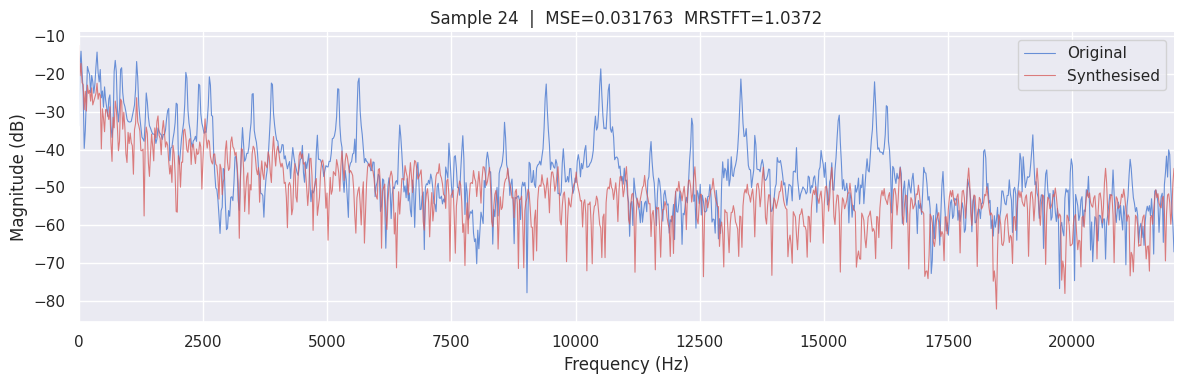

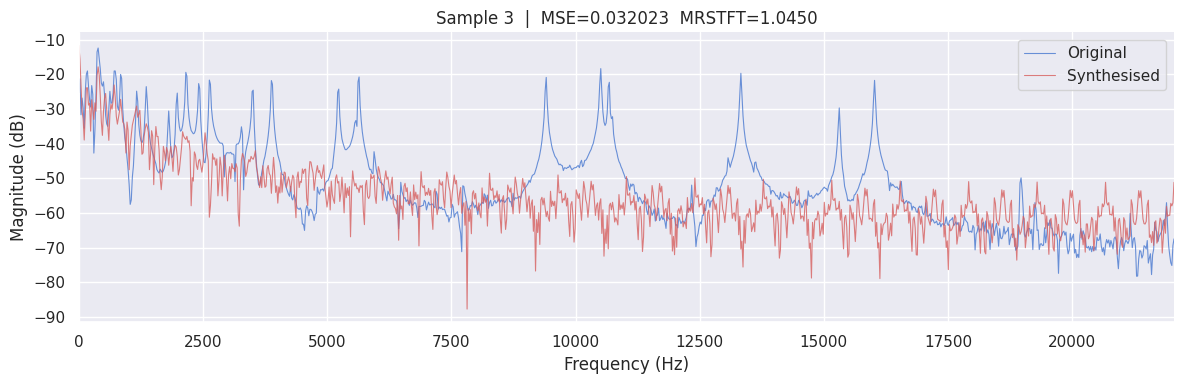

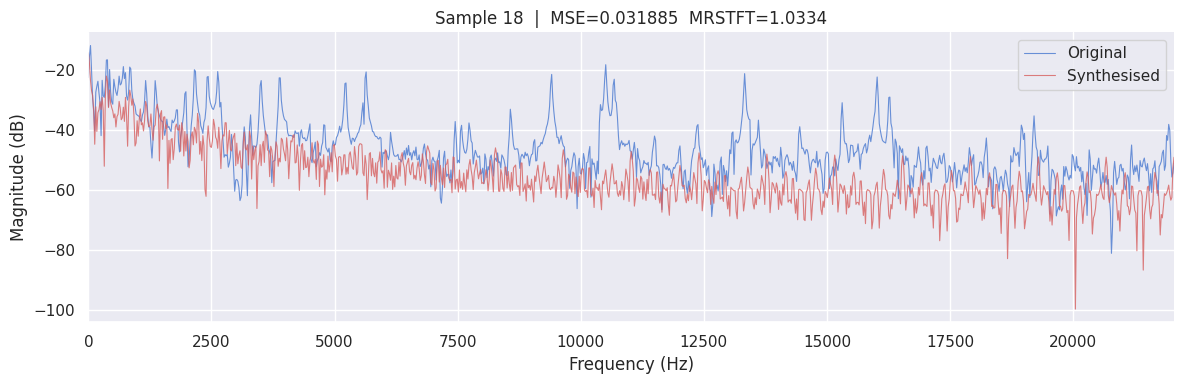

In [9]:
def plot_spectrum(x: np.ndarray, y: np.ndarray, sr: int, title: str = ""):
    """Plot overlaid magnitude spectra of original (x) and synthesised (y).

    Applies a Hann window to reduce spectral leakage.
    """
    n_fft = 2048
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    # Apply Hann window to reduce spectral leakage
    window = np.hanning(len(x))
    x_windowed = x * window
    y_windowed = y * window

    X = np.abs(np.fft.rfft(x_windowed, n=n_fft))
    Y = np.abs(np.fft.rfft(y_windowed, n=n_fft))

    # Convert to dB
    X_db = 20 * np.log10(X + 1e-8)
    Y_db = 20 * np.log10(Y + 1e-8)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(freqs, X_db, color=sns.color_palette()[0], alpha=0.8, linewidth=0.8, label="Original")
    ax.plot(freqs, Y_db, color=sns.color_palette()[3], alpha=0.8, linewidth=0.8, label="Synthesised")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(title or "Magnitude Spectrum")
    ax.legend(frameon=True, fancybox=True)
    ax.set_xlim(0, sr / 2)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


for r in results:
    plot_spectrum(r["x"], r["y"], SAMPLE_RATE,
                 title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}")

## 5 - Waveform comparison

/tmp/ipykernel_2934363/327524456.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


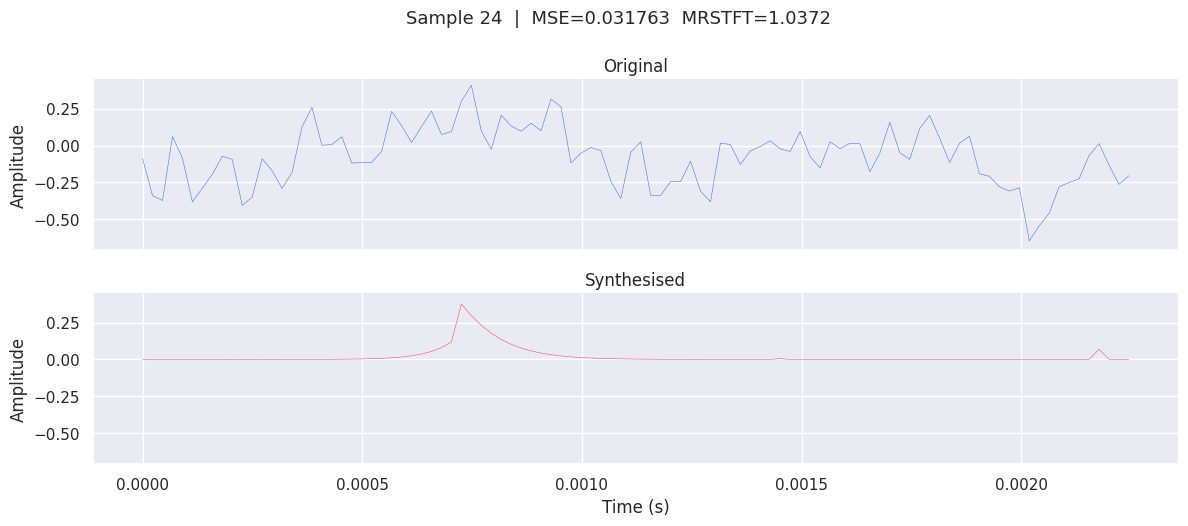

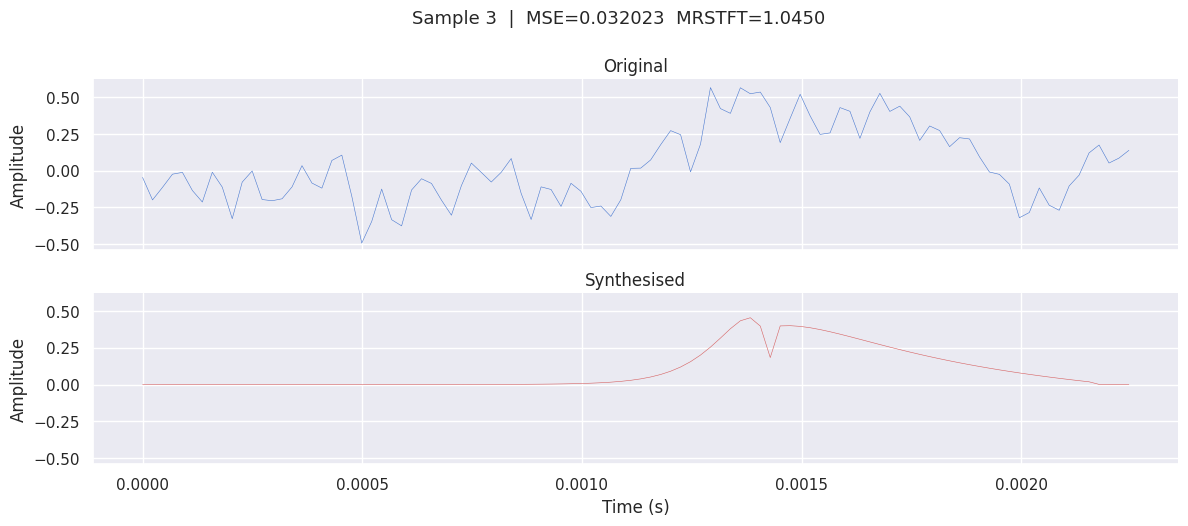

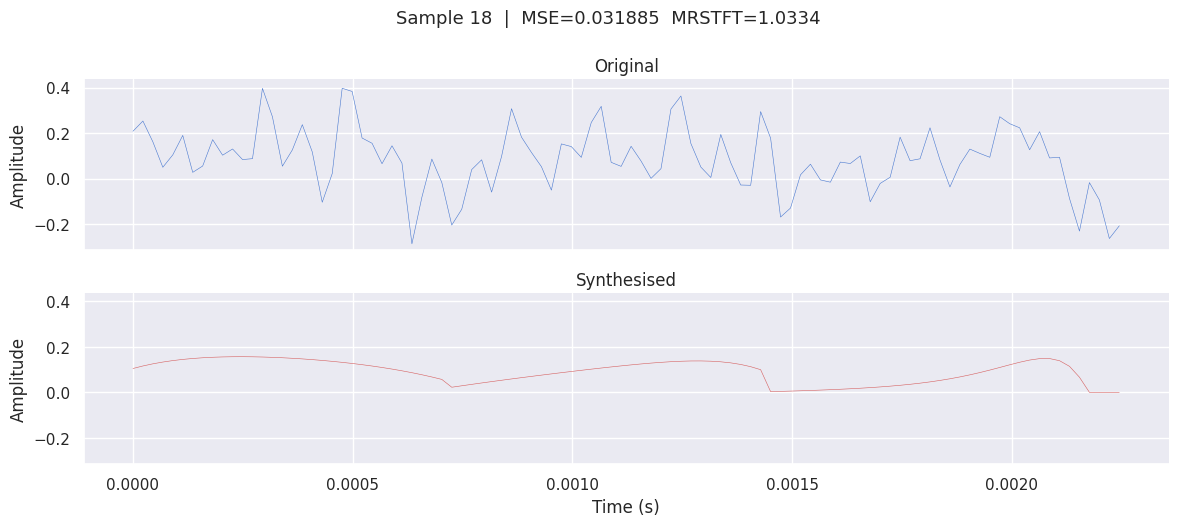

In [10]:
def plot_waveforms(x: np.ndarray, y: np.ndarray, sr: int, title: str = "",
                   display_samples: int | None = None):
    """Plot original and synthesised waveforms stacked vertically.

    Args:
        x: Original waveform
        y: Synthesised waveform
        sr: Sample rate
        title: Plot title
        display_samples: Number of samples to display from the beginning.
                        If None, displays the entire waveform.
    """
    if display_samples is not None:
        x = x[:display_samples]
        y = y[:display_samples]

    t = np.arange(len(x)) / sr

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                             gridspec_kw={"hspace": 0.25})

    axes[0].plot(t, x, color=sns.color_palette()[0], linewidth=0.4)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Original")

    axes[1].plot(t, y, color=sns.color_palette()[3], linewidth=0.4)
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("Synthesised")
    axes[1].set_xlabel("Time (s)")

    # Sync y-axis limits
    ymin = min(x.min(), y.min()) * 1.1
    ymax = max(x.max(), y.max()) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    fig.suptitle(title or "Waveform comparison", fontsize=13, y=1.02)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


# Number of samples to display (set to None for full waveform, or e.g. 4410 for 0.1s @ 44.1kHz)
DISPLAY_SAMPLES = 100  # Try: int(0.1 * SAMPLE_RATE) for first 100ms

for r in results:
    plot_waveforms(r["x"], r["y"], SAMPLE_RATE,
                   title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}",
                   display_samples=DISPLAY_SAMPLES)

## 6 - Audio playback

In [11]:
for r in results:
    print(f"\n=== Sample {r['idx']} ===")
    print("Original:")
    display(Audio(r["x"], rate=SAMPLE_RATE))
    print("Synthesised:")
    display(Audio(r["y"], rate=SAMPLE_RATE))


=== Sample 24 ===
Original:


Synthesised:



=== Sample 3 ===
Original:


Synthesised:



=== Sample 18 ===
Original:


Synthesised:
